In [134]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes

import typing

In [135]:
# Default parameters
# TODO -- rename them to constants
N = 641
L = np.float64(100.0)
cfl = np.float64(0.5)
advection = np.float64(1.0)
sigma = np.float64(0.8)
max_time = np.float64(50.0)

In [136]:
# Initial conditions

def gaussian_pulse(grid: npt.NDArray[np.floating],
                   center, width) -> npt.NDArray[np.floating]:
    return np.exp(-((grid - center) / width) ** 2)


def square_wave(grid: npt.NDArray[np.floating],
                center, width) -> npt.NDArray[np.floating]:
    return np.where(np.abs(grid - center) <= width, 1.0, 0.0)


def sine_wave(grid: npt.NDArray[np.floating],
              wavenumber: int) -> npt.NDArray[np.floating]:
    return np.sin(wavenumber * grid)


def left_triangle(grid: npt.NDArray[np.floating],
                  l1, l2) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = (grid[mask] - l1) / (l2 - l1)
    return result


def rectangle(grid: npt.NDArray[np.floating],
              l1, l2) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = 1.0
    return result


def wave(grid: npt.NDArray[np.floating], l1, l2) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = 0.5 * (1 - np.cos(2 * np.pi * (grid[mask] - l1) / (l2 - l1)))
    return result


def tooth(grid: npt.NDArray[np.floating],
          l1, l2, l11, l22) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)

    mask1 = (grid >= l1) & (grid < l11)
    result[mask1] = -(2/3) * (grid[mask1] - l1) / (l11 - l1) + 1

    mask2 = (grid >= l11) & (grid <= l22)
    result[mask2] = 1/3

    mask3 = (grid > l22) & (grid <= l2)
    result[mask3] = (2/3) * (grid[mask3] - l2) / (l2 - l22) + 1

    return result


def letter_m(grid: npt.NDArray[np.floating],
             l1, l2, l12=None) -> npt.NDArray[np.floating]:
    l12 = l12 or (l1 + l2) / 2.0
    result = np.zeros_like(grid)

    mask1 = (grid >= l1) & (grid < l12)
    result[mask1] = -(2/3) * (grid[mask1] - l1) / (l12 - l1) + 1

    mask2 = (grid >= l12) & (grid <= l2)
    result[mask2] = (2/3) * (grid[mask2] - l2) / (l2 - l12) + 1

    return result


def right_triangle(grid: npt.NDArray[np.floating],
                   l1, l2) -> npt.NDArray[np.floating]:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = (l2 - grid[mask]) / (l2 - l1)
    return result

In [137]:
BoundaryType = typing.Literal['absorbing', 'periodic', 'fixed', 'extrapolation']

def apply_bc(
        u: np.typing.NDArray[np.floating],
        advection: np.typing.NDArray[np.floating] | None = None,
        bc_type: BoundaryType = 'periodic') -> np.typing.NDArray[np.floating]:

    match bc_type:
        case 'absorbing':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-2] = u[-3]
                u[-1] = u[-2]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[1] = u[2]
                u[0] = u[1]
        case 'periodic':
            u[0] = u[-4]
            u[1] = u[-3]
            u[-2] = u[2]
            u[-1] = u[3]
        case 'fixed':
            u[0] = 0.0
            u[1] = 0.0
            u[-2] = 0.0
            u[-1] = 0.0
        case 'extrapolation':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-1] = 3.0 * u[-2] - 3.0 * u[-3] + u[-4]
                u[-2] = 3.0 * u[-3] - 3.0 * u[-4] + u[-5]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[0] = 3.0 * u[1] - 3.0 * u[2] + u[3]
                u[1] = 3.0 * u[2] - 3.0 * u[3] + u[4]

    return u

In [138]:
ICFunc = typing.Callable[..., npt.NDArray[np.floating]]


def exact_solution(grid: npt.NDArray[np.floating],
                   ic_func: ICFunc,
                   ic_kwargs: dict,
                   advection: np.floating,
                   time: np.floating,
                   bc_type: BoundaryType,
                   L: np.floating) -> npt.NDArray[np.floating]:
    shifted = grid - advection * time
    if bc_type == "periodic":
        shifted = shifted % L
    return ic_func(shifted, **ic_kwargs)

In [139]:
from mlf_method import mlf_step

# Reload for prototyping and interactivity
import importlib; import mlf_method; importlib.reload(mlf_method); # noqa: E702

In [140]:
def rusanov_step(
    u: npt.NDArray[np.floating], *, cfl: np.floating, **_
) -> npt.NDArray[np.floating]:
    cfl2 = cfl * cfl
    cfl3 = cfl2 * cfl
    omega = (4.0 * cfl2 + 1.0) * (4.0 - cfl2) / 5.0

    u_next = np.zeros_like(u)
    i = np.arange(2, len(u) - 2)
    u_next[i] = (
        u[i]
        - cfl / 12.0 * (-u[i+2] + 8.0*u[i+1] - 8.0*u[i-1] + u[i-2])
        + cfl2 / 8.0 * (u[i+2] - 2.0*u[i] + u[i-2])
        - cfl3 / 12.0 * (u[i+2] - 2.0*u[i+1] + 2.0*u[i-1] - u[i-2])
        - omega / 24.0 * (u[i+2] - 4.0*u[i+1] + 6.0*u[i] - 4.0*u[i-1] + u[i-2])
    )
    return u_next


def mlf_with_correction_step(
    u: npt.NDArray[np.floating], *,
    sigma: np.floating, cfl: np.floating, dx: np.floating,
    **_,
) -> npt.NDArray[np.floating]:
    cfl2 = cfl * cfl

    u_next = mlf_step(u, sigma=sigma, cfl=cfl, dx=dx)

    i = np.arange(2, len(u) - 2)
    # Fall back to lower-order scheme at non-smooth points (local extrema)
    oscillation = (u_next[i+1] - u_next[i]) * (u_next[i] - u_next[i-1]) < 0.0
    u_low = (
        sigma * u[i]
        + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
        - 0.5 * cfl * (u[i+1] - u[i-1])
        + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
    )
    u_next[i] = np.where(oscillation, u_low, u_next[i])

    return u_next

In [160]:
StepFunc = typing.Callable[..., npt.NDArray[np.floating]]


def advect(
        step_func: StepFunc, N: int = N, L: np.floating = L, cfl: np.floating = cfl,
        advection: np.floating = advection, sigma: np.floating = sigma,
        max_time: np.floating = max_time, bc_type: BoundaryType = "periodic",
        step_func_kwargs: dict = {},
        ic_func: ICFunc = gaussian_pulse,
        ic_kwargs: dict = {"center": 20.0, "width": 5.0},):
    dx = L / (N - 1.0)
    grid = np.linspace(0.0, (N - 1) * dx, N)

    time = np.float64(0)

    u = ic_func(grid, **ic_kwargs)

    while time <= max_time:
        dt = dx * cfl / advection
        time += dt

        u = apply_bc(u)
        u: npt.NDArray[np.floating] = step_func(u, sigma=sigma, cfl=cfl, dx=dx, a=advection, dt=dt, **step_func_kwargs)

    u_exact = exact_solution(grid, ic_func, ic_kwargs,
                             advection, time, bc_type, L)

    return grid, u, u_exact

In [161]:
grid, u, u_exact = advect(mlf_step)
error = np.abs(u - u_exact)
grid, u_rusanov, u_exact = advect(rusanov_step)
error_rusanov = np.abs(u_rusanov - u_exact)

dx = L / (N - 1.0)

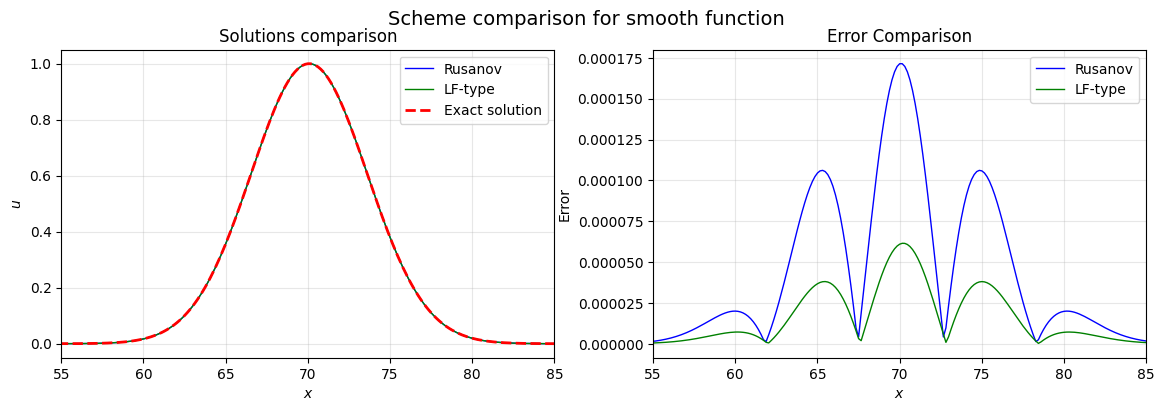

In [162]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='Rusanov')
plt.plot(grid, u, 'g-', linewidth=1, label='LF-type')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlim(55, 85)
# plt.xlim(70 - 0.01, 70 + 0.01)
# plt.ylim(1 - 0.01, 1 + 0.01)
plt.xlabel('$x$')
plt.ylabel('$u$')
plt.title('Solutions comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Rusanov')
plt.plot(grid, error, 'g-', linewidth=1, label='LF-type')
plt.xlabel('$x$')
plt.xlim(55, 85)
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Scheme comparison for smooth function', fontsize=14)
plt.show()

In [163]:
mesh_sizes = [51, 101, 201, 401, 801, 1601,]
dxs = np.array(L / (np.array(mesh_sizes) - 1))
ps = (1, 2, np.inf)


def convergence(
        mesh_sizes: typing.Sequence[int] = mesh_sizes,
        ps: typing.Sequence[float] = ps,
        **kws,
) -> dict[float, np.ndarray]:
    """
    Compute L_p errors for arbitrary p values.

    Returns
    -------
    errors: dict[p, np.ndarray]
        Mapping from p to array of errors (aligned with mesh_sizes).
    """
    def lp_error(error: np.ndarray, p: float) -> np.floating:
        return np.max(error) if p == np.inf else np.mean(np.abs(error)**p)**(1 / p)

    errors = {p: np.zeros(len(mesh_sizes)) for p in ps}

    for i, N in enumerate(mesh_sizes):
        _, u, u_exact = advect(N=N, **kws)

        error = np.abs(u - u_exact)

        for p in ps:
            errors[p][i] = lp_error(error, p)

    return errors

In [164]:
import matplotlib.axes
import matplotlib.ticker


def plot_convergence(
    dxs: np.ndarray,
    errors: dict[float, np.ndarray],
    expected_order: int,
    axes: typing.Sequence[matplotlib.axes.Axes] | None = None,
    **kws
):
    """
    Plots convergence data for multiple methods across multiple norms.

    Args:
        results: Nested dict {method_name: {p: errors}}.
        dxs: Array of mesh spacings (for the x-axis).
        expected_orders: dict {method_name: theoretical_order}.
        axes: Optional pre-existing axes to plot on.
    """

    if axes is None:
        fig, axes = plt.subplots(1, len(errors), figsize=(5 * len(errors), 4))
        # Place for a suptitle
        fig.set_layout_engine(rect=[0, 0.03, 1, 0.95])
        # Ensure axes is always a list-like object for consistency
        axes = typing.cast(typing.Sequence[matplotlib.axes.Axes],
                           [axes] if len(errors) == 1 else axes)
    else:
        fig = axes[0].figure

    for ax, (p, error) in zip(axes, errors.items(), strict=True):
        ax.loglog(mesh_sizes, error, 'o--', linewidth=2, **kws)

        reference = error[0] * (np.array(dxs) / dxs[0])**expected_order
        ax.loglog(
            mesh_sizes, reference,
            label=fr'${expected_order}^{{\text{{th}}}}$-order',
            color=ax.lines[-1].get_color(),  # Match color of method
            linestyle=':', linewidth=1.5
        )

        ax.set_xlabel(r'Mesh size $\propto 1/\Delta x$')
        ax.set_ylabel('Error')
        ax.set_title(r"$L_\infty$" if p == np.inf else f"$L_{int(p)}$" " norm")
        ax.legend()
        ax.grid(True, which='major', alpha=0.3)

        ax.set_xticks(mesh_sizes, minor=False)
        ax.minorticks_off()
        ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

    return fig, axes

In [165]:
dxs = L / np.array(mesh_sizes)

mlf_convergence = convergence(
    step_func=mlf_step, mesh_sizes=mesh_sizes, sigma=0.5, cfl=0.5, max_time=10
)
rusanov_convergence = convergence(
    step_func=rusanov_step, mesh_sizes=mesh_sizes, sigma=0.5, cfl=0.5, max_time=10
)

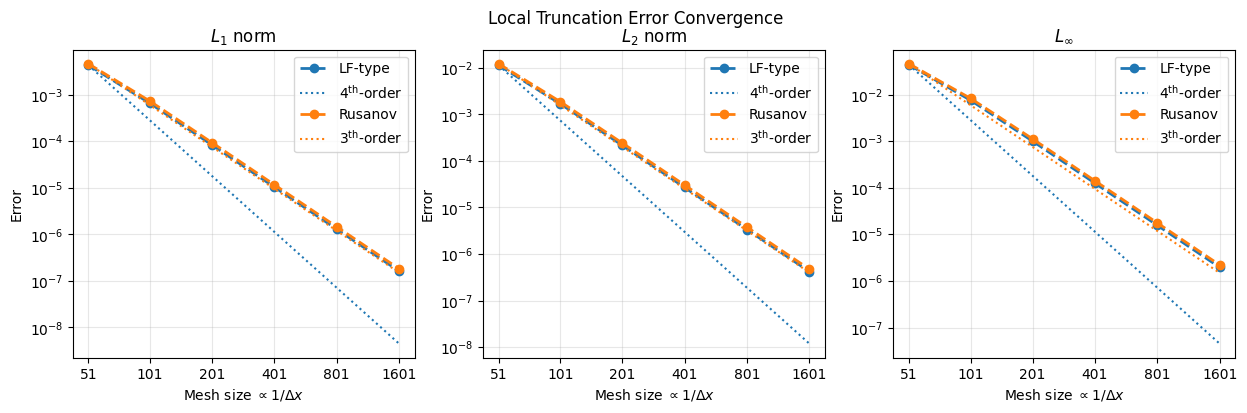

In [ ]:
fig, axes = plot_convergence(
    dxs, errors=mlf_convergence, expected_order=4, label="LF-type")
fig, axes = plot_convergence(
    dxs, errors=rusanov_convergence, expected_order=3, label="Rusanov",
    axes=axes)

fig.suptitle("Global Truncation Error Convergence")

plt.show()

In [167]:
print("Mesh size [" + " ".join([f"{size:>6d}" for size in mesh_sizes]) + "]\n")
np.set_printoptions(precision=2)
for method_name, errors in zip(
    ("Rusanov", "LF-type"),
    (rusanov_convergence, mlf_convergence)
):
    print(method_name)
    for p, error in errors.items():
        print(f"L_{'inf' if p ==np.inf else p :<7} {np.log2(error)}")
    print()

Mesh size [    51    101    201    401    801   1601]

Rusanov
L_1       [ -7.75 -10.42 -13.38 -16.38 -19.38 -22.39]
L_2       [ -6.34  -9.05 -12.01 -15.01 -18.01 -21.02]
L_inf     [ -4.44  -6.91  -9.8  -12.79 -15.79 -18.79]

LF-type
L_1       [ -7.85 -10.57 -13.54 -16.55 -19.55 -22.56]
L_2       [ -6.45  -9.2  -12.17 -15.18 -18.18 -21.19]
L_inf     [ -4.51  -7.04  -9.96 -12.95 -15.96 -18.96]



In [168]:
dxs = L / np.array(mesh_sizes)

mlf_convergence = convergence(
    step_func=mlf_step, mesh_sizes=mesh_sizes, sigma=0.5, cfl=0.5, max_time=0
)
rusanov_convergence = convergence(
    step_func=rusanov_step, mesh_sizes=mesh_sizes, sigma=0.5, cfl=0.5, max_time=0
)

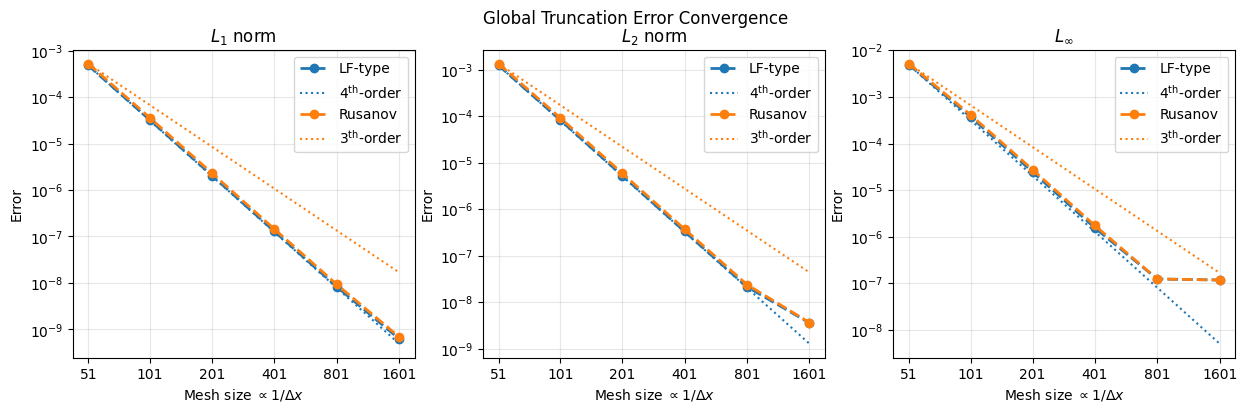

In [ ]:
fig, axes = plot_convergence(
    dxs, errors=mlf_convergence, expected_order=4, label="LF-type")
fig, axes = plot_convergence(
    dxs, errors=rusanov_convergence, expected_order=3, label="Rusanov",
    axes=axes)

fig.suptitle("Local Truncation Error Convergence")

plt.show()

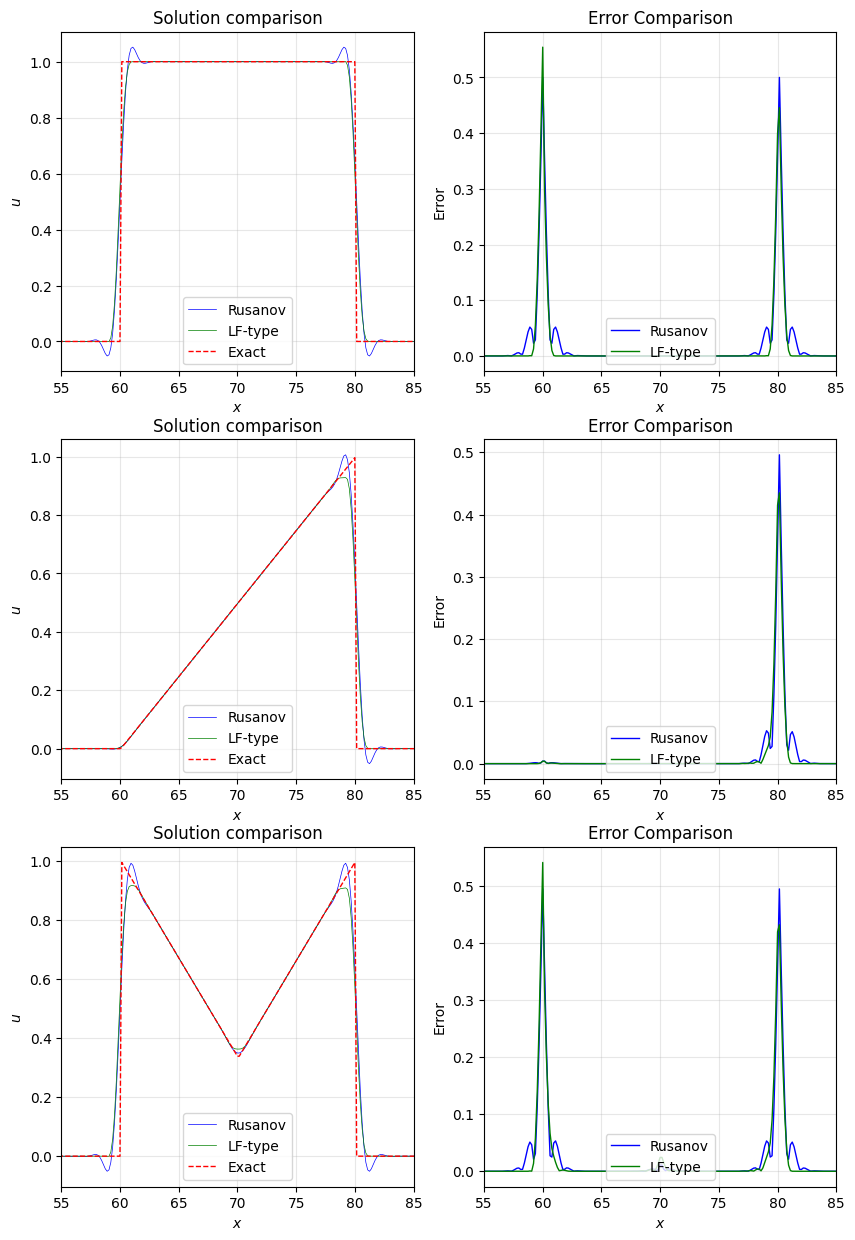

In [ ]:
plt.figure(figsize=(10, 15))

for i, (ic_func, ic_kwargs) in enumerate(
    zip(
        [
            # rectangle,
            # left_triangle,
            letter_m,
            # gaussian_pulse,
        ],
        [
            # {"l1": 10.0, "l2": 30.0},
            # {"l1": 10.0, "l2": 30.0},
            {"l1": 10.0, "l2": 30.0},
            # {"center": 20.0, "width": 5.0},
        ])):
    grid, u, u_exact = advect(
        mlf_with_correction_step,
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )
    grid, u_rusanov, u_exact = advect(
        rusanov_step,
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )

    plt.subplot(3, 2, 2 * i + 1)

    plt.plot(grid, u_rusanov, 'b-', linewidth=0.5, label='Rusanov')
    plt.plot(grid, u, 'g-', linewidth=0.5, label='LF-type')
    plt.plot(grid, u_exact, 'r--', linewidth=1, label='Exact')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('$u$')
    plt.title('Solution comparison')
    plt.legend(loc='lower center')
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 2, 2 * i + 2)
    error_rusanov = np.abs(u_rusanov - u_exact)
    error = np.abs(u - u_exact)

    plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Rusanov')
    plt.plot(grid, error, 'g-', linewidth=1, label='LF-type')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('Error')
    plt.title('Error Comparison')
    plt.legend(loc='lower center')
    plt.grid(True, alpha=0.3)

plt.show()

In [171]:
def curvature_sensor(u: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Returns S_i (len(u)-2) for interior cells i=1..n-2."""
    im1, i, ip1 = slice(0,-2), slice(1,-1), slice(2,None)
    num = np.abs(u[im1] - 2.0*u[i] + u[ip1])
    den = np.abs(u[im1] - u[i]) + np.abs(u[i] - u[ip1]) + eps
    return num / den

def local_variation_sensor(u: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Wider stencil, len(u)-4 for cells 2..n-3."""
    idx = np.arange(2, len(u)-2)
    num = np.abs(u[idx+1] - 2.0*u[idx] + u[idx-1])
    den = (np.abs(u[idx+2] - u[idx+1]) + np.abs(u[idx+1] - u[idx]) +
           np.abs(u[idx] - u[idx-1]) + np.abs(u[idx-1] - u[idx-2]) + eps)
    S = 1.0 - num/den
    return np.clip(S, 0.0, 1.0)

def hode_sensor(u: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """High‑order derivative sensor, len(u)-4."""
    idx = np.arange(2, len(u)-2)
    d3a = np.abs(u[idx+2] - 3.0*u[idx+1] + 3.0*u[idx] - u[idx-1])
    d3b = np.abs(u[idx+1] - 3.0*u[idx] + 3.0*u[idx-1] - u[idx-2])
    var = np.abs(u[idx+1] - u[idx-1]) + eps
    S = 1.0 / (1.0 + (d3a + d3b) / var)
    return np.clip(S, 0.0, 1.0)

def pad_sensor(S_partial: np.ndarray, n: int) -> np.ndarray:
    """Extend interior sensor to full length n."""
    m = len(S_partial)
    if m == n: return S_partial
    S_full = np.zeros(n)
    if m == n-2:        # from curvature_sensor
        S_full[1:-1] = S_partial
        S_full[0], S_full[-1] = S_partial[0], S_partial[-1]
    elif m == n-4:      # from local_variation/hode
        S_full[2:-2] = S_partial
        S_full[0] = S_full[1] = S_partial[0]
        S_full[-1] = S_full[-2] = S_partial[-1]
    else:
        raise ValueError(f"Sensor length {m} unexpected for n={n}")
    return S_full

In [ ]:
def aav_step(
    u: np.ndarray,
    dx: float, cfl: float, sigma: float, a: float,
    sensor: typing.Callable = curvature_sensor,
    C: float = 0.5,
    **mlf_args
) -> np.ndarray:
    """
    One step of advection with adaptive artificial viscosity.

    Parameters
    ----------
    u : 1D array, current solution.
    dx : grid spacing.
    cfl : CFL number = |velocity| * dt / dx.
    sigma : parameter passed to mlf_step.
    velocity : advection speed (a).
    sensor : function mapping u -> S_interior (0=shock, 1=smooth).
    C : scaling constant for viscosity.
    """
    u_ho = mlf_step(u, dx=dx, cfl=cfl, sigma=sigma, **mlf_args)

    S_partial = sensor(u)
    S = pad_sensor(S_partial, len(u))

    # Cell‑centred viscosity coefficient
    nu = C * dx * np.abs(a) * (1.0 - S)

    # Interface viscosities (harmonic mean) – shape (n-1,)
    eps_nu = 1e-15
    nu_int = 2.0 / (1.0 / (nu[:-1] + eps_nu) + 1.0 / (nu[1:] + eps_nu))

    # Viscous fluxes F_{i+1/2} = nu_int * (u_{i+1} - u_i) / dx
    du_dx = np.diff(u_ho) / dx   # length n-1
    visc_flux = nu_int * du_dx

    # Add viscous flux contribution (interior cells only)
    u_out = u_ho.copy()
    # (cfl * dx / |a|) = dt, making the addition: dt * (1/dx)*divergence
    u_out[1:-1] += (cfl * dx / np.abs(a)) * (visc_flux[1:] - visc_flux[:-1]) / dx

    return u_out

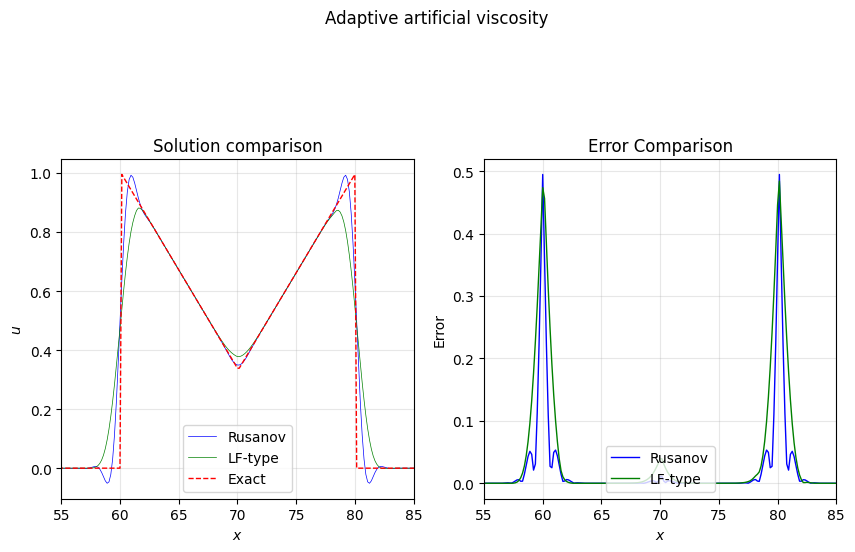

In [208]:
plt.figure(figsize=(10, 15))

for i, (ic_func, ic_kwargs) in enumerate(
    zip(
        [
            # rectangle,
            # left_triangle,
            letter_m,
            # gaussian_pulse,
        ],
        [
            # {"l1": 10.0, "l2": 30.0},
            # {"l1": 10.0, "l2": 30.0},
            {"l1": 10.0, "l2": 30.0},
            # {"center": 20.0, "width": 5.0},
         ])):
    grid, u, u_exact = advect(
            aav_step,
            step_func_kwargs=dict(C=0.05),
            ic_func=ic_func,
            ic_kwargs=ic_kwargs,
        )
    grid, u_rusanov, u_exact = advect(
            rusanov_step,
            ic_func=ic_func,
            ic_kwargs=ic_kwargs,
        )

    plt.subplot(3, 2, 2 * i + 1)

    plt.plot(grid, u_rusanov, 'b-', linewidth=0.5, label='Rusanov')
    plt.plot(grid, u, 'g-', linewidth=0.5, label='LF-type')
    plt.plot(grid, u_exact, 'r--', linewidth=1, label='Exact')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('$u$')
    plt.title('Solution comparison')
    plt.legend(loc='lower center')
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 2, 2 * i + 2)
    error_rusanov = np.abs(u_rusanov - u_exact)
    error = np.abs(u - u_exact)

    plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Rusanov')
    plt.plot(grid, error, 'g-', linewidth=1, label='LF-type')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('Error')
    plt.title('Error Comparison')
    plt.legend(loc='lower center')
    plt.grid(True, alpha=0.3)

plt.suptitle("Adaptive artificial viscosity")
plt.show()

In [ ]:
def low_order_step(u: np.ndarray, cfl: float, sigma: float) -> np.ndarray:
    cfl2 = cfl * cfl
    i = np.arange(1, len(u)-1)
    u_low = (
        sigma * u[i]
        + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
        - 0.5 * cfl * (u[i+1] - u[i-1])
        + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
    )
    # keep boundaries unchanged
    u_new = u.copy()
    u_new[1:-1] = u_low
    return u_new

The scheme **exactly preserves conservation** and can probably be proven to be Total‑Variation‑Bounded (TVB) if the ramp ensures that near shocks the flux becomes purely upwind

In [ ]:
def hybrid_mlf_step(
    u: np.ndarray,
    dx: float, cfl: float, sigma: float, a: float,
    sensor: typing.Callable = curvature_sensor,
    sensor_ramp: typing.Callable = lambda s: s,   # identity: weight = S directly
    **mlf_kwargs
) -> np.ndarray:
    """
    Hybrid scheme that blends mlf_step (4th order) with the 3‑point low‑order fallback.
    The blending weight w_i ∈ [0,1] is sensor_ramp(S_i).
    * S_i ≈ 0 → w_i ≈ 0 → low‑order (dissipative, monotone)
    * S_i ≈ 1 → w_i ≈ 1 → full 4th‑order accuracy
    """
    # High‑order update
    u_high = mlf_step(u, dx=dx, cfl=cfl, sigma=sigma, **mlf_kwargs)

    # Low‑order update
    # TODO -- this probably should be a parameter, so we can use Upwind for example
    u_low = low_order_step(u, cfl=cfl, sigma=sigma)

    # Sensor and blending weight
    S_partial = sensor(u)
    S = pad_sensor(S_partial, len(u))
    w_cell = np.clip(sensor_ramp(S), 0.0, 1.0)

    # Blend only for interior cells where both stencils are valid
    i_interior = np.arange(2, len(u)-2)
    u_new = u_high.copy()
    u_new[i_interior] = (
        w_cell[i_interior]      * u_high[i_interior] +
        (1.0 - w_cell[i_interior]) * u_low[i_interior]
    )
    return u_new

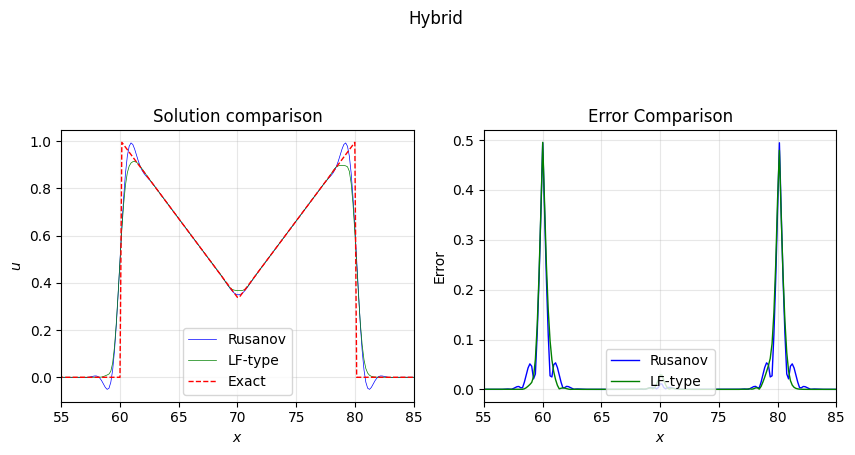

In [ ]:
plt.figure(figsize=(10, 15))

for i, (ic_func, ic_kwargs) in enumerate(
    zip(
        [
            # rectangle,
            # left_triangle,
            letter_m,
            # gaussian_pulse,
        ],
        [
            # {"l1": 10.0, "l2": 30.0},
            # {"l1": 10.0, "l2": 30.0},
            {"l1": 10.0, "l2": 30.0},
            #  {"center": 20.0, "width": 5.0},
        ])):
    grid, u, u_exact = advect(
        hybrid_mlf_step,
        step_func_kwargs=dict(sensor=hode_sensor,
                              sensor_ramp=lambda s: np.clip(3*s-1, 0, 1)),
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )
    grid, u_rusanov, u_exact = advect(
        rusanov_step,
        ic_func=ic_func,
        ic_kwargs=ic_kwargs,
    )

    plt.subplot(3, 2, 2 * i + 1)

    plt.plot(grid, u_rusanov, 'b-', linewidth=0.5, label='Rusanov')
    plt.plot(grid, u, 'g-', linewidth=0.5, label='LF-type')
    plt.plot(grid, u_exact, 'r--', linewidth=1, label='Exact')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('$u$')
    plt.title('Solution comparison')
    plt.legend(loc='lower center')
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 2, 2 * i + 2)
    error_rusanov = np.abs(u_rusanov - u_exact)
    error = np.abs(u - u_exact)

    plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Rusanov')
    plt.plot(grid, error, 'g-', linewidth=1, label='LF-type')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('Error')
    plt.title('Error Comparison')
    plt.legend(loc='lower center')
    plt.grid(True, alpha=0.3)

plt.suptitle("Hybrid")
plt.show()